# Experiment No. 07: Frequency Hopping Spread Spectrum

## Title

**Implementation of Frequency Hopping Spread Spectrum using Python**

## Aim

To generate a Frequency Hopping Spread Spectrum signal using a pseudo-random hopping sequence and recover the original binary data through synchronized dehopping and demodulation.

## Experimental Requirements

- Python 3
- Jupyter Notebook or Google Colab
- NumPy
- Matplotlib

## Theory

Spread Spectrum is a communication technique in which the bandwidth of a signal is expanded to a bandwidth much larger than the minimum bandwidth required to transmit the original information.

If the original signal bandwidth is \(B\), the spread-spectrum bandwidth is represented by

$$
B_{\text{SS}} \gg B
$$

The spreading operation is controlled by a code that is independent of the original information signal.

The two commonly used spread-spectrum techniques are:

1. Frequency Hopping Spread Spectrum
2. Direct Sequence Spread Spectrum

## Frequency Hopping Spread Spectrum

Frequency Hopping Spread Spectrum, or FHSS, uses several carrier frequencies instead of transmitting continuously at one fixed carrier frequency.

At one hopping interval, the information signal is transmitted using one carrier frequency. During the next hopping interval, another carrier frequency is selected.

Although only one carrier frequency is used at a particular moment, several frequencies are used over the complete transmission period.

If there are \(M\) available hopping frequencies, the required number of PN-code bits is approximately

$$
k = \left\lceil \log_2 M \right\rceil
$$

For seven hopping frequencies,

$$
M = 7
$$

and therefore,

$$
k = \left\lceil \log_2 7 \right\rceil = 3
$$

A three-bit code is therefore sufficient to identify the available frequency channels.

## Main Components of an FHSS System

An FHSS transmitter contains:

1. Binary data source
2. Digital modulator
3. Pseudo-random or PN-code generator
4. Frequency table
5. Frequency synthesizer
6. Mixer
7. Communication channel

The PN-code generator produces a pseudo-random code during every hopping period. The code selects a frequency from the frequency table, and the frequency synthesizer generates the corresponding carrier.

## Laboratory Implementation Note

The supplied laboratory block diagram represents an M-ary FSK-based FHSS system. However, the supplied MATLAB program first generates a BPSK signal and then multiplies it by a seven-frequency spreading carrier.

The Python implementation follows this MATLAB-program structure:

**Binary Data → Polar NRZ → BPSK Modulator → Mixer → FHSS Signal**

At the receiver:

**Received FHSS Signal → Synchronized Mixer → BPSK Detector → Recovered Data**

## Binary Data Representation

For a binary input sequence \(b[n]\), polar NRZ mapping is used:

$$
m[n] =
\begin{cases}
+1, & b[n]=1 \\
-1, & b[n]=0
\end{cases}
$$

## BPSK Signal

The polar binary signal modulates a base carrier:

$$
s_{\text{BPSK}}(t)
=
m(t)\cos(2\pi f_b t)
$$

where:

- \(m(t)\) is the polar binary waveform,
- \(f_b\) is the BPSK carrier frequency.

## Frequency-Hopping Carrier

The PN sequence selects a hopping frequency \(f_h[n]\) during each bit or hopping interval.

The hopping carrier is

$$
c_h(t)
=
\cos(2\pi f_h[n]t)
$$

where \(f_h[n]\) is selected from the available frequency set

$$
F =
\{f_1,f_2,\ldots,f_M\}
$$

## FHSS Signal Generation

Following the supplied MATLAB program, the BPSK signal is multiplied by the selected hopping carrier:

$$
s_{\text{FHSS}}(t)
=
s_{\text{BPSK}}(t)c_h(t)
$$

Therefore,

$$
s_{\text{FHSS}}(t)
=
m(t)\cos(2\pi f_b t)
\cos(2\pi f_h[n]t)
$$

Using the product-to-sum identity,

$$
\cos A\cos B
=
\frac{1}{2}
\left[
\cos(A+B)+\cos(A-B)
\right]
$$

the mixer produces frequency components around

$$
f_h[n]+f_b
$$

and

$$
f_h[n]-f_b
$$

As the PN sequence changes, the transmitted frequency components move from one frequency region to another.

## FHSS Receiver

The receiver must know the same hopping sequence used by the transmitter.

A synchronized local PN generator selects the same hopping frequency during each hopping interval. The received signal is multiplied by the corresponding local hopping carrier:

$$
r_d(t)
=
2r(t)c_h(t)
$$

This operation removes the frequency-hopping effect and approximately recovers the original BPSK signal.

The dehopped signal is then correlated with the original BPSK carrier.

For the \(n\)-th bit, the decision variable is

$$
z[n]
=
\sum r_d(t)\cos(2\pi f_b t)
$$

The recovered bit is determined using a zero threshold:

$$
\hat{b}[n]
=
\begin{cases}
1, & z[n]\geq 0 \\
0, & z[n]<0
\end{cases}
$$

## Synchronization

Correct FHSS reception requires the transmitter and receiver to use:

- The same hopping-frequency set
- The same PN sequence
- The same starting position
- The same hopping period
- Proper timing synchronization

An incorrect local hopping sequence prevents proper dehopping and causes data-detection errors.

## Slow and Fast Frequency Hopping

### Slow Frequency Hopping

In slow frequency hopping, one hopping frequency is used for one or more data symbols.

$$
T_h \geq T_s
$$

where:

- \(T_h\) is the hopping period,
- \(T_s\) is the symbol period.

### Fast Frequency Hopping

In fast frequency hopping, the carrier changes several times during one data symbol.

$$
T_h < T_s
$$

This experiment uses one selected hopping frequency for each binary bit and therefore represents symbol-synchronous frequency hopping.

## Advantages of FHSS

- The signal does not remain at one carrier frequency for a long time.
- It provides resistance against narrowband interference.
- It provides protection against intentional jamming.
- A receiver that does not know the hopping sequence has difficulty following the transmission.
- Several users may use different hopping sequences over the same frequency range.

## Limitations of FHSS

- The transmitter and receiver require accurate synchronization.
- A frequency synthesizer is required.
- The available bandwidth is larger than the original signal bandwidth.
- An incorrect hopping sequence produces unsuccessful recovery.
- Rapid hopping increases implementation complexity.

## Algorithm

1. Generate a random binary data sequence.
2. Convert binary `0` and `1` into polar values `-1` and `+1`.
3. Generate a base carrier for BPSK modulation.
4. Multiply the polar data waveform by the base carrier.
5. Define seven available hopping frequencies.
6. Generate a reproducible pseudo-random hopping sequence.
7. Select one hopping frequency for every bit interval.
8. Generate the frequency-hopping carrier.
9. Multiply the BPSK signal by the hopping carrier.
10. Produce the Frequency Hopping Spread Spectrum signal.
11. Generate the same synchronized hopping carrier at the receiver.
12. Multiply the received signal by the synchronized carrier to dehop it.
13. Correlate the dehopped signal with the BPSK carrier.
14. Apply a zero-threshold decision rule.
15. Recover the original binary sequence.
16. Calculate the number of bit errors and Bit Error Rate.
17. Plot the input, BPSK, hopping, FHSS, dehopped, and recovered signals.

## Output

The program displays:

1. Original binary data sequence
2. BPSK-modulated signal
3. PN-controlled hopping-frequency sequence
4. Seven-frequency spreading carrier
5. Frequency Hopping Spread Spectrum signal
6. Dehopped BPSK signal
7. Recovered binary data
8. Input and recovered bit sequences
9. Number of bit errors
10. Bit Error Rate

## Result and Discussion

The binary information signal was converted into polar NRZ form and modulated using BPSK. A pseudo-random hopping sequence selected one of seven available frequencies during every bit interval.

The BPSK signal was multiplied by the selected hopping carrier to produce the FHSS signal. The waveform changed its frequency according to the PN-controlled hopping sequence.

At the receiver, the same synchronized hopping carrier was used to remove the frequency-hopping effect. Correlation with the original BPSK carrier recovered the transmitted bits.

In an ideal noiseless and synchronized channel, the recovered binary sequence matches the transmitted sequence and the Bit Error Rate is zero.

## Conclusion

Frequency Hopping Spread Spectrum was successfully implemented using Python. The experiment demonstrated BPSK modulation, PN-controlled frequency selection, frequency hopping, synchronized dehopping, data detection, and Bit Error Rate calculation.

The experiment also showed that successful recovery depends on accurate synchronization between the transmitter and receiver hopping sequences.

FREQUENCY HOPPING SPREAD SPECTRUM
Input binary sequence     : 1 1 1 1 1 1 1 0 0 0 0 1 1 0 0 1 0 1 0 0
PN hop indices            : 4 2 5 7 6 3 1 3 5 1 4 2 6 7 1 6 5 2 7 3
Three-bit PN code words   : 011 001 100 110 101 010 000 010 100 000 011 001 101 110 000 101 100 001 110 010
Selected hop frequencies  : 4 12 3 1 2 6 24 6 3 24 4 12 2 1 24 2 3 12 1 6 cycles/bit
Recovered binary sequence : 1 1 1 1 1 1 1 0 0 0 0 1 1 0 0 1 0 1 0 0
Decision metrics          : [ 0.5   0.5   0.5   0.75  0.5   0.5   0.5  -0.5  -0.5  -0.5  -0.5   0.5
  0.5  -0.75 -0.5   0.5  -0.5   0.5  -0.75 -0.5 ]
Number of bit errors      : 0
Bit Error Rate            : 0.0


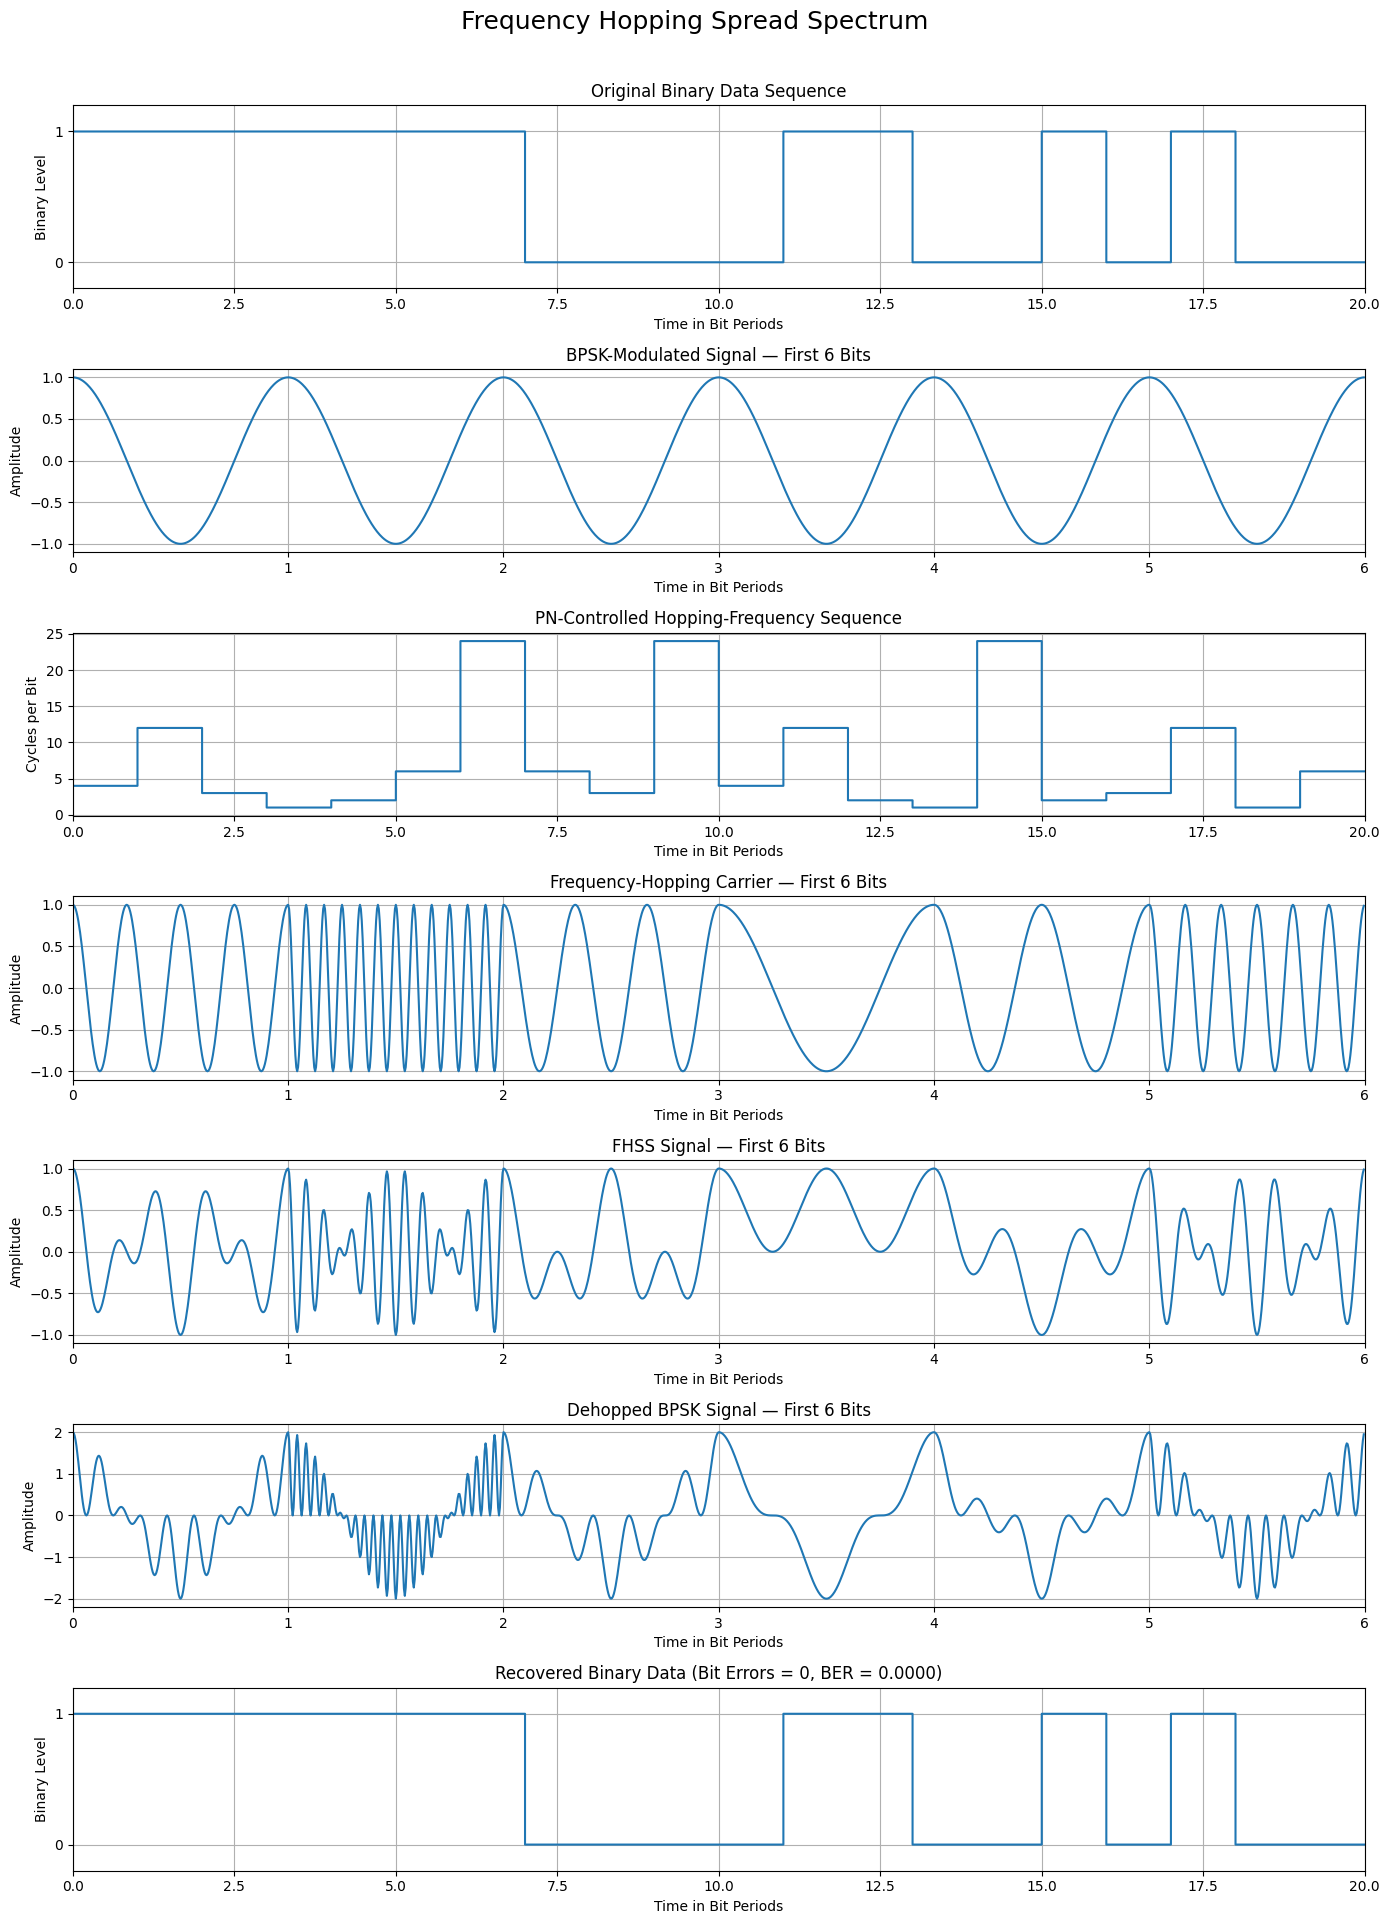

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# EXPERIMENT PARAMETERS
# ============================================================

# Fixed seed makes the experiment reproducible.
random_seed = 7
rng = np.random.default_rng(random_seed)

# Number of binary information bits
number_of_bits = 20

# Number of samples used to represent one bit
samples_per_bit = 240

# Normalized bit duration
bit_duration = 1.0

# Base BPSK carrier frequency in cycles per bit
base_carrier_frequency = 1.0

# Seven normalized hopping frequencies.
#
# These values represent the seven carrier patterns used in
# the supplied MATLAB laboratory program.
hop_frequencies = np.array(
    [24, 12, 6, 4, 3, 2, 1],
    dtype=float
)

number_of_hop_frequencies = len(hop_frequencies)


# ============================================================
# GENERATE BINARY INFORMATION
# ============================================================

binary_data = rng.integers(
    low=0,
    high=2,
    size=number_of_bits
)

# Polar NRZ conversion:
# Binary 0 -> -1
# Binary 1 -> +1
polar_data = 2 * binary_data - 1


# ============================================================
# GENERATE A PSEUDO-RANDOM HOPPING SEQUENCE
# ============================================================

# Generate enough shuffled frequency-index blocks to cover
# the complete binary sequence.
number_of_blocks = int(
    np.ceil(number_of_bits / number_of_hop_frequencies)
)

pn_hop_indices = np.concatenate(
    [
        rng.permutation(number_of_hop_frequencies)
        for _ in range(number_of_blocks)
    ]
)[:number_of_bits]

# Frequency selected during every bit interval
selected_hop_frequencies = hop_frequencies[pn_hop_indices]

# Convert the hop indices to three-bit PN words.
pn_code_words = [
    format(index, "03b")
    for index in pn_hop_indices
]


# ============================================================
# TIME AXES
# ============================================================

# Local time axis for one bit interval
local_time = (
    np.arange(samples_per_bit)
    / samples_per_bit
    * bit_duration
)

# Complete time axis
total_samples = number_of_bits * samples_per_bit

time = (
    np.arange(total_samples)
    / samples_per_bit
    * bit_duration
)


# ============================================================
# CREATE BINARY AND POLAR WAVEFORMS
# ============================================================

binary_waveform = np.repeat(
    binary_data,
    samples_per_bit
)

polar_waveform = np.repeat(
    polar_data,
    samples_per_bit
)


# ============================================================
# BPSK MODULATION
# ============================================================

# Base carrier during one bit interval
base_carrier_one_bit = np.cos(
    2
    * np.pi
    * base_carrier_frequency
    * local_time
)

# Repeat the base carrier for every bit
base_carrier = np.tile(
    base_carrier_one_bit,
    number_of_bits
)

# BPSK signal
bpsk_signal = polar_waveform * base_carrier


# ============================================================
# GENERATE THE FREQUENCY-HOPPING CARRIER
# ============================================================

hopping_carrier = np.zeros(
    total_samples,
    dtype=float
)

for bit_index, hop_frequency in enumerate(
    selected_hop_frequencies
):
    start = bit_index * samples_per_bit
    stop = start + samples_per_bit

    hopping_carrier[start:stop] = np.cos(
        2
        * np.pi
        * hop_frequency
        * local_time
    )


# A waveform containing the selected frequency value
# during each bit interval
frequency_sequence_waveform = np.repeat(
    selected_hop_frequencies,
    samples_per_bit
)


# ============================================================
# FREQUENCY HOPPING SPREAD SPECTRUM TRANSMITTER
# ============================================================

# Mixer output:
# FHSS signal = BPSK signal x hopping carrier
fhss_signal = bpsk_signal * hopping_carrier


# ============================================================
# IDEAL SYNCHRONIZED FHSS RECEIVER
# ============================================================

# The receiver generates exactly the same hopping carrier.
receiver_hopping_carrier = hopping_carrier.copy()

# Dehopping operation
#
# The multiplication by 2 compensates for the 1/2 factor
# introduced by cosine multiplication.
dehopped_signal = (
    2
    * fhss_signal
    * receiver_hopping_carrier
)


# ============================================================
# BPSK CORRELATION DETECTOR
# ============================================================

decision_metric = np.zeros(
    number_of_bits,
    dtype=float
)

recovered_bits = np.zeros(
    number_of_bits,
    dtype=int
)

for bit_index in range(number_of_bits):
    start = bit_index * samples_per_bit
    stop = start + samples_per_bit

    # Correlate the dehopped signal with the BPSK carrier.
    decision_metric[bit_index] = np.mean(
        dehopped_signal[start:stop]
        * base_carrier[start:stop]
    )

    # Zero-threshold decision
    recovered_bits[bit_index] = int(
        decision_metric[bit_index] >= 0
    )


recovered_binary_waveform = np.repeat(
    recovered_bits,
    samples_per_bit
)


# ============================================================
# BIT ERROR RATE
# ============================================================

bit_errors = np.count_nonzero(
    binary_data != recovered_bits
)

bit_error_rate = (
    bit_errors / number_of_bits
)


# ============================================================
# DISPLAY NUMERICAL RESULTS
# ============================================================

print("=" * 75)
print("FREQUENCY HOPPING SPREAD SPECTRUM")
print("=" * 75)

print(
    "Input binary sequence     :",
    " ".join(binary_data.astype(str))
)

print(
    "PN hop indices            :",
    " ".join(
        (pn_hop_indices + 1).astype(str)
    )
)

print(
    "Three-bit PN code words   :",
    " ".join(pn_code_words)
)

print(
    "Selected hop frequencies  :",
    " ".join(
        selected_hop_frequencies.astype(int).astype(str)
    ),
    "cycles/bit"
)

print(
    "Recovered binary sequence :",
    " ".join(recovered_bits.astype(str))
)

print(
    "Decision metrics          :",
    np.round(decision_metric, 4)
)

print("Number of bit errors      :", bit_errors)
print("Bit Error Rate            :", bit_error_rate)

print("=" * 75)


# ============================================================
# PLOTTING
# ============================================================

# The high-frequency continuous waveforms are displayed for
# only the first few bits so that their changes remain visible.
display_bits = 6
display_samples = display_bits * samples_per_bit

plt.figure(figsize=(14, 19))


# ------------------------------------------------------------
# 1. Original binary sequence
# ------------------------------------------------------------

plt.subplot(7, 1, 1)

plt.step(
    time,
    binary_waveform,
    where="post"
)

plt.title("Original Binary Data Sequence")
plt.xlabel("Time in Bit Periods")
plt.ylabel("Binary Level")
plt.yticks([0, 1])
plt.ylim(-0.2, 1.2)
plt.xlim(0, number_of_bits)
plt.grid()


# ------------------------------------------------------------
# 2. BPSK-modulated signal
# ------------------------------------------------------------

plt.subplot(7, 1, 2)

plt.plot(
    time[:display_samples],
    bpsk_signal[:display_samples]
)

plt.title(
    f"BPSK-Modulated Signal — First {display_bits} Bits"
)

plt.xlabel("Time in Bit Periods")
plt.ylabel("Amplitude")
plt.xlim(0, display_bits)
plt.grid()


# ------------------------------------------------------------
# 3. PN-selected hopping-frequency sequence
# ------------------------------------------------------------

plt.subplot(7, 1, 3)

plt.step(
    time,
    frequency_sequence_waveform,
    where="post"
)

plt.title("PN-Controlled Hopping-Frequency Sequence")
plt.xlabel("Time in Bit Periods")
plt.ylabel("Cycles per Bit")
plt.xlim(0, number_of_bits)
plt.grid()


# ------------------------------------------------------------
# 4. Seven-frequency spreading carrier
# ------------------------------------------------------------

plt.subplot(7, 1, 4)

plt.plot(
    time[:display_samples],
    hopping_carrier[:display_samples]
)

plt.title(
    f"Frequency-Hopping Carrier — First {display_bits} Bits"
)

plt.xlabel("Time in Bit Periods")
plt.ylabel("Amplitude")
plt.xlim(0, display_bits)
plt.grid()


# ------------------------------------------------------------
# 5. Frequency Hopping Spread Spectrum signal
# ------------------------------------------------------------

plt.subplot(7, 1, 5)

plt.plot(
    time[:display_samples],
    fhss_signal[:display_samples]
)

plt.title(
    f"FHSS Signal — First {display_bits} Bits"
)

plt.xlabel("Time in Bit Periods")
plt.ylabel("Amplitude")
plt.xlim(0, display_bits)
plt.grid()


# ------------------------------------------------------------
# 6. Dehopped signal
# ------------------------------------------------------------

plt.subplot(7, 1, 6)

plt.plot(
    time[:display_samples],
    dehopped_signal[:display_samples]
)

plt.title(
    f"Dehopped BPSK Signal — First {display_bits} Bits"
)

plt.xlabel("Time in Bit Periods")
plt.ylabel("Amplitude")
plt.xlim(0, display_bits)
plt.grid()


# ------------------------------------------------------------
# 7. Recovered binary sequence
# ------------------------------------------------------------

plt.subplot(7, 1, 7)

plt.step(
    time,
    recovered_binary_waveform,
    where="post"
)

plt.title(
    "Recovered Binary Data "
    f"(Bit Errors = {bit_errors}, BER = {bit_error_rate:.4f})"
)

plt.xlabel("Time in Bit Periods")
plt.ylabel("Binary Level")
plt.yticks([0, 1])
plt.ylim(-0.2, 1.2)
plt.xlim(0, number_of_bits)
plt.grid()


plt.suptitle(
    "Frequency Hopping Spread Spectrum",
    fontsize=18,
    y=1.01
)

plt.tight_layout()
plt.show()